# Baseline Models
## Phase 3: Classification without Stopword Removal

This notebook establishes the baseline classification performance on Reuters-21578
using TF-IDF features with **no stopword removal**.

Models:
- Naive Bayes (MultinomialNB)
- Logistic Regression
- Support Vector Machine (LinearSVC)

Metrics:
- Accuracy, Precision, Recall, F1-Score
- Training time
- Feature space size
- Confusion matrix

## Setup and Imports

In [1]:
import sys
import os
import time
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)

sys.path.append(os.path.abspath('..'))

from src.preprocessing.text_cleaner import TextCleaner
from src.preprocessing.stopword_handler import StopwordHandler
from src.models.feature_extractor import FeatureExtractor
from src.models.classifier import TextClassifier
from src.evaluation.metrics import ModelEvaluator

sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100

print('✅ Imports successful')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ROHAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ROHAN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ROHAN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Imports successful


## Load and Prepare Data

In [2]:
DATA_PATH = Path('../data/processed/reuters_with_analysis.csv')

df = pd.read_csv(DATA_PATH)

# Parse topics and assign single label
df['topics'] = df['topics'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df['label'] = df['topics'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)
df = df.dropna(subset=['label', 'body'])

# Keep only labels with >= 5 documents
label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts >= 5].index
df_filtered = df[df['label'].isin(valid_labels)].copy()

print('=' * 70)
print('DATASET LOADED')
print('=' * 70)
print(f'Total articles (with body + label) : {len(df)}')
print(f'After label filtering (>= 5 docs)  : {len(df_filtered)}')
print(f'Unique categories                  : {df_filtered["label"].nunique()}')
print(f'\nTop 10 categories:')
print(df_filtered['label'].value_counts().head(10).to_string())

DATASET LOADED
Total articles (with body + label) : 10377
After label filtering (>= 5 docs)  : 10324
Unique categories                  : 55

Top 10 categories:
label
earn        3761
acq         2186
money-fx     574
grain        489
crude        483
trade        441
interest     263
ship         204
sugar        145
coffee       124


---
# 1. Preprocessing — No Stopword Removal (Baseline)
## Clean text only, retain all tokens

In [3]:
cleaner = TextCleaner()

print('🔄 Applying text cleaning (no stopword removal)...')

texts = []
for text in df_filtered['body']:
    cleaned = cleaner.clean(text)
    tokens = cleaner.tokenize_and_process(cleaned)
    texts.append(' '.join(tokens))

labels = df_filtered['label'].tolist()

print(f'✅ Preprocessed {len(texts)} articles')
print(f'\nSample preprocessed text:')
print(texts[0][:200])

🔄 Applying text cleaning (no stopword removal)...
✅ Preprocessed 10324 articles

Sample preprocessed text:
showers continued throughout the week in the bahia cocoa zone alleviating the drought since early january and improving prospects for the coming temporao although normal humidity levels have not been 


In [4]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print('=' * 70)
print('TRAIN / TEST SPLIT')
print('=' * 70)
print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print(f'Split ratio      : 80 / 20')
print(f'Random seed      : 42 (stratified)')

TRAIN / TEST SPLIT
Training samples : 8259
Test samples     : 2065
Split ratio      : 80 / 20
Random seed      : 42 (stratified)


---
# 2. Feature Extraction — TF-IDF (No Stopwords)
## Building the baseline feature matrix

In [5]:
feature_extractor = FeatureExtractor(method='tfidf', stopword_strategy='none')

X_train_tfidf = feature_extractor.fit_transform(X_train)
X_test_tfidf  = feature_extractor.transform(X_test)

print('=' * 70)
print('TF-IDF FEATURE MATRIX — BASELINE (No Stopwords)')
print('=' * 70)
print(f'Training matrix shape : {X_train_tfidf.shape}')
print(f'Test matrix shape     : {X_test_tfidf.shape}')
print(f'Number of features    : {X_train_tfidf.shape[1]}')
print(f'Matrix sparsity       : {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.4%}')

TF-IDF FEATURE MATRIX — BASELINE (No Stopwords)
Training matrix shape : (8259, 14794)
Test matrix shape     : (2065, 14794)
Number of features    : 14794
Matrix sparsity       : 99.5320%


---
# 3. Train and Evaluate Baseline Models

In [6]:
evaluator = ModelEvaluator()
baseline_results = []

models_to_run = [
    ('nb',  'Naive Bayes'),
    ('lr',  'Logistic Regression'),
    ('svm', 'Support Vector Machine'),
]

print('=' * 70)
print('TRAINING BASELINE MODELS')
print('=' * 70)

for model_key, model_name in models_to_run:
    print(f'\n🔄 Training {model_name}...')

    classifier = TextClassifier(model_type=model_key)

    start = time.time()
    classifier.train(X_train_tfidf, y_train)
    train_time = time.time() - start

    y_pred = classifier.predict(X_test_tfidf)
    metrics = evaluator.evaluate(y_test, y_pred)

    result = {
        'model': model_name,
        'model_key': model_key,
        'stopword_strategy': 'none',
        'num_features': X_train_tfidf.shape[1],
        'training_time_sec': round(train_time, 4),
        **metrics
    }
    baseline_results.append(result)

    print(f'   ✅ Done in {train_time:.2f}s')
    print(f'      Accuracy  : {metrics["accuracy"]:.4f}')
    print(f'      F1-Score  : {metrics["f1_score"]:.4f}')

baseline_df = pd.DataFrame(baseline_results)
print('\n✅ All baseline models trained.')

TRAINING BASELINE MODELS

🔄 Training Naive Bayes...
   ✅ Done in 0.07s
      Accuracy  : 0.6809
      F1-Score  : 0.5951

🔄 Training Logistic Regression...
   ✅ Done in 12.46s
      Accuracy  : 0.8644
      F1-Score  : 0.8430

🔄 Training Support Vector Machine...
   ✅ Done in 1.29s
      Accuracy  : 0.9109
      F1-Score  : 0.9058

✅ All baseline models trained.


In [7]:
print('=' * 70)
print('BASELINE RESULTS SUMMARY')
print('=' * 70)
display_cols = ['model', 'num_features', 'training_time_sec', 'accuracy', 'precision', 'recall', 'f1_score']
baseline_df[display_cols]

BASELINE RESULTS SUMMARY


,model,num_features,training_time_sec,accuracy,precision,recall,f1_score
0,Naive Bayes,14794,0.0680,0.680872,0.548661,0.680872,0.595056
1,Logistic Regression,14794,12.4607,0.864407,0.846350,0.864407,0.843023
2,Support Vector Machine,14794,1.2893,0.910896,0.907316,0.910896,0.905832


---
# 4. Detailed Classification Report — Best Baseline Model (SVM)

In [8]:
# Re-train SVM for detailed report
svm_clf = TextClassifier(model_type='svm')
svm_clf.train(X_train_tfidf, y_train)
y_pred_svm = svm_clf.predict(X_test_tfidf)

print('=' * 70)
print('DETAILED CLASSIFICATION REPORT — SVM (Baseline)')
print('=' * 70)
print(classification_report(y_test, y_pred_svm, zero_division=0))

DETAILED CLASSIFICATION REPORT — SVM (Baseline)
                 precision    recall  f1-score   support

            acq       0.91      0.97      0.94       437
           alum       0.91      1.00      0.95        10
            bop       0.44      0.44      0.44         9
        carcass       0.56      0.83      0.67         6
          cocoa       1.00      0.83      0.91        12
         coffee       0.96      0.88      0.92        25
         copper       1.00      1.00      1.00        12
           corn       0.00      0.00      0.00         1
         cotton       0.83      1.00      0.91         5
            cpi       0.70      0.93      0.80        15
          crude       0.84      0.88      0.86        97
            dlr       0.00      0.00      0.00         7
           earn       0.98      0.98      0.98       752
           fuel       1.00      0.33      0.50         3
            gas       1.00      0.43      0.60         7
            gnp       0.67      0.96   

---
# 5. Baseline Visualizations

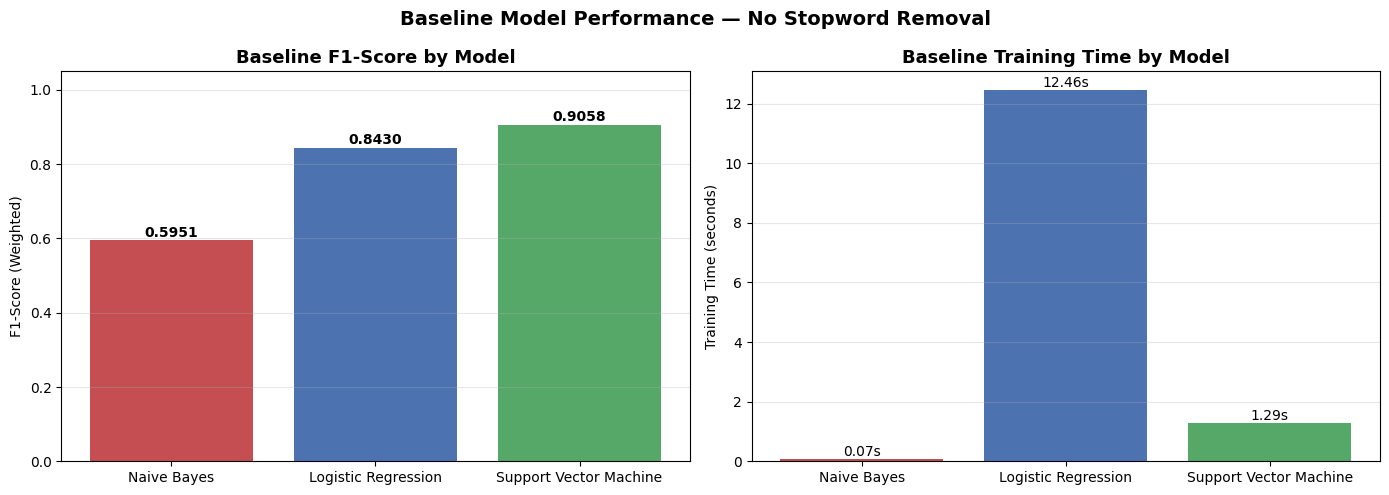

✅ Saved: results/figures/baseline_model_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_labels = [r['model'] for r in baseline_results]
f1_scores     = [r['f1_score'] for r in baseline_results]
accuracies    = [r['accuracy'] for r in baseline_results]
train_times   = [r['training_time_sec'] for r in baseline_results]
colors = ['#C44E52', '#4C72B0', '#55A868']

# F1 Scores
bars = axes[0].bar(models_labels, f1_scores, color=colors)
axes[0].set_title('Baseline F1-Score by Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('F1-Score (Weighted)')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# Training Time
bars2 = axes[1].bar(models_labels, train_times, color=colors)
axes[1].set_title('Baseline Training Time by Model', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}s', ha='center', fontsize=10)

plt.suptitle('Baseline Model Performance — No Stopword Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/baseline_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: results/figures/baseline_model_comparison.png')

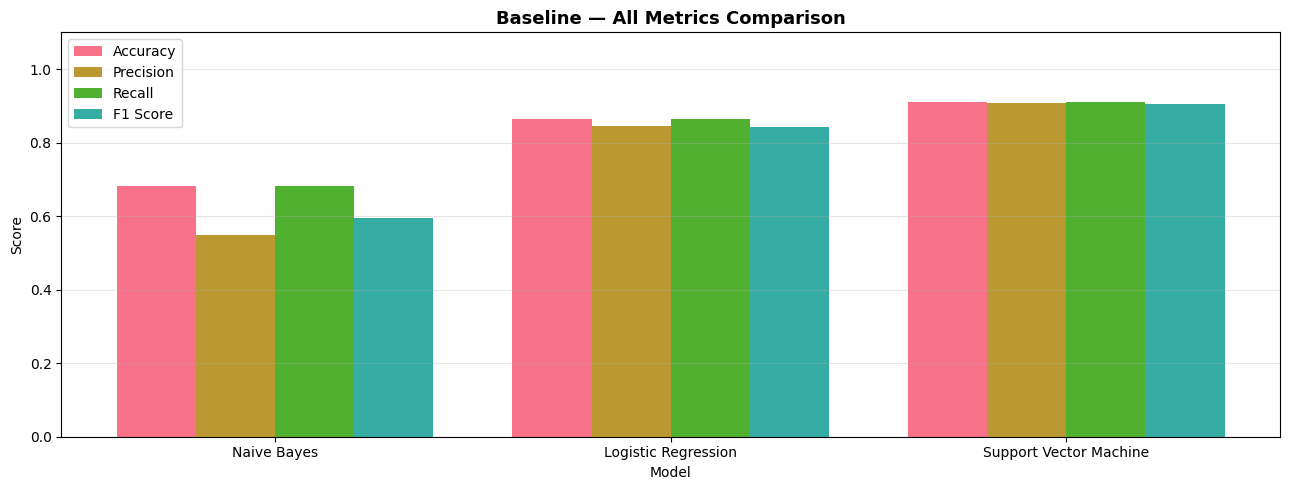

✅ Saved: results/figures/baseline_all_metrics.png


In [10]:
# All 4 metrics side by side
metrics_list = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(models_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 5))

for i, metric in enumerate(metrics_list):
    vals = [r[metric] for r in baseline_results]
    bars = ax.bar(x + i * width, vals, width, label=metric.replace('_', ' ').title())

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Baseline — All Metrics Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models_labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/baseline_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: results/figures/baseline_all_metrics.png')

---
# 6. Save Baseline Results

In [11]:
BASELINE_PATH = Path('../results/tables/baseline_results.csv')
baseline_df.to_csv(BASELINE_PATH, index=False)
print(f'✅ Baseline results saved to: {BASELINE_PATH}')

print('\n' + '=' * 70)
print('BASELINE SUMMARY')
print('=' * 70)
print(f"""
1️⃣  Feature Space (No stopwords): {X_train_tfidf.shape[1]} features

2️⃣  Model Performance:
   - Naive Bayes         : F1 = {baseline_df[baseline_df['model_key']=='nb']['f1_score'].values[0]:.4f}  (weakest)
   - Logistic Regression : F1 = {baseline_df[baseline_df['model_key']=='lr']['f1_score'].values[0]:.4f}
   - SVM                 : F1 = {baseline_df[baseline_df['model_key']=='svm']['f1_score'].values[0]:.4f}  (strongest)

3️⃣  Key Observations:
   - SVM dramatically outperforms Naive Bayes at baseline
   - High feature count (14,794) does not hurt SVM
   - NB is most sensitive to noisy high-frequency features
   - These baselines will be compared against stopword removal in notebook 04
""")

✅ Baseline results saved to: ..\results\tables\baseline_results.csv

BASELINE SUMMARY

1️⃣  Feature Space (No stopwords): 14794 features

2️⃣  Model Performance:
   - Naive Bayes         : F1 = 0.5951  (weakest)
   - Logistic Regression : F1 = 0.8430
   - SVM                 : F1 = 0.9058  (strongest)

3️⃣  Key Observations:
   - SVM dramatically outperforms Naive Bayes at baseline
   - High feature count (14,794) does not hurt SVM
   - NB is most sensitive to noisy high-frequency features
   - These baselines will be compared against stopword removal in notebook 04

